<a href="https://colab.research.google.com/github/aamirahpersaud/DSC_110/blob/main/week9_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linear Regression**

In [1]:
#import libraries
import pandas as pd
from sklearn.linear_model import LinearRegression

This comment explains the creation of the new DataFrame project.

In [3]:
X = pd.DataFrame({'age': [20, 30, 40, 50, 60]})
y = [110, 115, 120, 125, 130]

Age is the key and the values are the list within this specific dictionary. The x is the independent variable. The outcome is then protected to define the target by finding the y variable. Y is the list. This replicates the table that displays the relationship between age and systolic pressure. Dictionaries always have the curvy brackets; always have a key and variable.

In [4]:
lr = LinearRegression()
lr.fit(X, y)

LinearRegression()

This creates a linear regression model from the sklearn.linear_model library. It is assigned the variable, lr.and the model is then trained. This analyzes the relationship between x and y data to find the best-fitting linear equation, calculating the slope and intercept that bets describes the relationship between age and the target variable. This function is made to predict. This will be be the base starter for the model being built.

In [7]:
ages_to_predict = pd.DataFrame({'age': [10, 45, 80]})

lr.predict(ages_to_predict)


array([105. , 122.5, 140. ])

This is for the new ages that want to be predicted. 105 is the expected value.

In [8]:
ages_to_predict = pd.DataFrame ({'age':[10, 45, 70]})
predictions = lr.predict(ages_to_predict)
print(predictions)

[105.  122.5 135. ]


This will generate the values from the predictions, simplifying the steps to determine the predictions by making it equal "pd".

In [9]:
for p in predictions:
  print(f"{p:.2f}")

105.00
122.50
135.00


"P" is used as an abbreviation to assign to "predictions" then the list is generated, rounding the numbers to a specific decimal point. Loops starts with "for." The loop is used to print predictions clearly with 2 decimals.


In [11]:
X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70]})
y = [0, 0, 0, 1, 1, 1]

lr = LinearRegression()
lr.fit(X, y)

diabetes_status_to_predict = pd.DataFrame({'age': [5, 45, 100]})
predictions = lr.predict(diabetes_status_to_predict)
for p in predictions:
    print(f"{p:.2f}")

-0.53
0.50
1.91


When the output is binary, the linear regression is predicted. The corressponding number of ys represents the outcome. The same list as diabetes is being predicted. The existence of diabetes for patients of specific ages is being predicted. The outputs are expected to be between 0 and 1.

**Logistic Regression**
models the probability of a binary outcome; is a classification.

In [13]:
from sklearn.linear_model import LogisticRegression
import numpy as np

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70]})
y =                       [0,  0,  0,  1,  1,  1]

lr = LogisticRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [5, 45, 100]})

probabilities = lr.predict_proba(ages_to_predict)

for p in probabilities[:, 1]:
    print(f"{p:.2f}")

0.00
0.50
1.00


In trying to predict binary outcomes, the logistic regression is necessary as part of the sklearn.
The data set is then created to be applied. X is used to predict Y; predict the diabetes status of patients based on their age. "Predict_probabilities" is used to do this. The output here cannot be below 1 or above 1.

In [15]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70, 80]})
y =  [0,  0,  1,  1,  1,  0,  0]

lr = LogisticRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [5, 25, 50, 75, 100]})
probabilities = lr.predict_proba(ages_to_predict)

for p in probabilities[:, 1]:
    print(f"{p:.2f}")

0.43
0.43
0.43
0.43
0.43


This displays the logistic regression when the outcome is not linear. The outcome here means that patients within that age group below 40 have a high risk of diabetes, but are above 60 do not. The risk is displayed to be the same regardless of the age.

**Decision Tree**

In [16]:
from sklearn.tree import DecisionTreeClassifier

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70, 80]})
y =  [0,  0,  1,  1,  1,  0,  0]

dt = DecisionTreeClassifier()
dt.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [25, 50, 75]})
probabilities = dt.predict(ages_to_predict)

for p in probabilities:
    print(f"{p:.2f}")

0.00
1.00
0.00


A new class was imported to find what was needed to predict. The probabilities are then predicted. The variable is created and learns patterns from the x and y data. It can detect specific points and creates a set of rules to split the data based on age to best predict the target. The depth of the tree is limited since the data is simple with only one variable.

Visual of Tree: This is used to visualize the tree, matching the data being used.

# **Applying Models On Our Own NHANES DataSet**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

The XgBoost overpreforms other models; it has sequential tree building. "Numpy" is used in python for higher arrays. Classification models are being worked with here to determine the rate of Diabetes. The classifier is necessary to differentiate this data from others. The "matrix" helps to highlight the classifier.

In [18]:
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

#to prevent warning, converting the y from df to 1d series
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

The data is being split into X and Y into columns and also by rows. These commands are used to score the model and see how well it is performing. "Squeeze" converts the Y test and Y train to a single array.

In [21]:
# Get a sanmple one patient from the test dataset to see
# if our models were able to accurately predict the outcome or not
patient = X_test.iloc[[243]]
patient

,age,bmi,height_cm,systolic_bp,gender_Male,race_ethnicity_Black,race_ethnicity_Mexican American,race_ethnicity_Other,race_ethnicity_Other Hispanic,race_ethnicity_White,education_College grad,education_Do not know,education_High school,education_Less than 9th,education_Some college
243,0.776425,1.479961,-0.391115,1.444984,False,False,False,False,False,True,False,False,True,False,False


We are testing a patient to test their outcome. The data is being scaled. The X_Test contains different features for different patients. The ".iloc" is used for selection by position in order to select data based on the integer position of its rows and columns, so it selected at position 243 from the X_test DataFrame. The double square brackets ensure that the output is still with a single row instead of a series.

In [23]:
actual = y_test.iloc[243]
print(actual)

1


This will test if the model accurately assesses and predicts if the selected patient has Diabetes or not.

**Logistic Regression**

In [24]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

This line is used to retrieve the true outcome for the same patient extracted from the X_test, testing how well the model performs. The y_test is used here to find a relationship between the inputs and outputs. The single square brackets are used here since y_test is a series, so it retrieves the outcome for the patient at index 243.

In [25]:
prediction = lr.predict(patient)[0]
print(prediction)

0


This analyzes what the logistic regression model did for the patient; the logistic regression says that they do not have Diabetes. This evaluates the accuracy of the model.

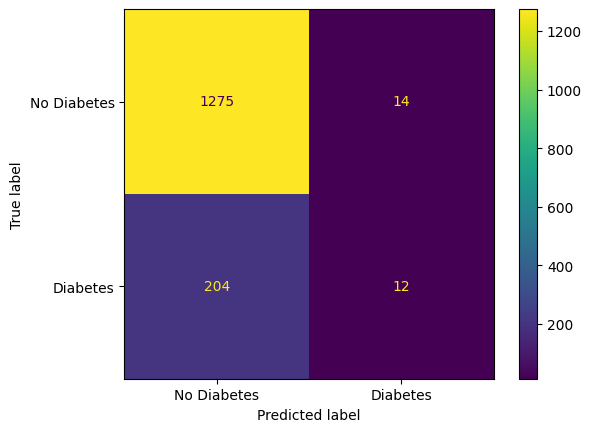

In [27]:
#See the model prediction for all the test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = lr.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

Instead of trying to predict the outcome of each patient, the Confusion Matrix is utilized to simplify this process and provide data for all other patients in the test set. This predicts the entire DataFrame of the X_test. y_pred is used for this test set to predict all observations rather than one. (like crosstabbing results from the model compared to actual results)

**Decision Tree**

In [28]:
dt = DecisionTreeClassifier(random_state=42) #random state used for reproducibility
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

This is used to build the model. This line is important for training the model on the data's target labels. These are the answers that the model was trying to predict. The tree will be built the same way, no matter how many times the code is ran.

In [29]:
prediction = dt.predict(patient)[0]
print(prediction)

0


The outcome of the same patient is being predicted.

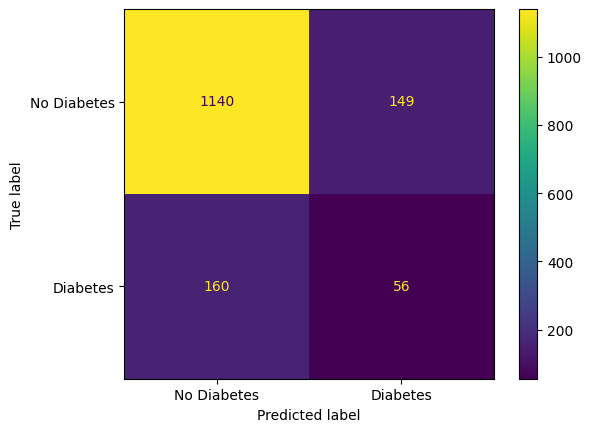

In [30]:
y_pred = dt.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

This command evaluates the trained model. This is used to make predictions on the X_test dataset. The predict() outputs the predicted class label for each patient in the X_test. The results of this variable are stored in the y_pred viarable, which will be an array containing the classification for each patient in the test set for this model.

**Random Forest**

In [31]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

This tests to see if the performance is better than the logistic regression or the tree. We are focusing on the data of the patient we have been tracking.

In [32]:
#Get the prediction for the patient we've been tracking throughout
prediction = rf.predict(patient)[0]
print(prediction)

1


This ensures that the extraction of data for the patient's predicted outcome is valid and accurate.

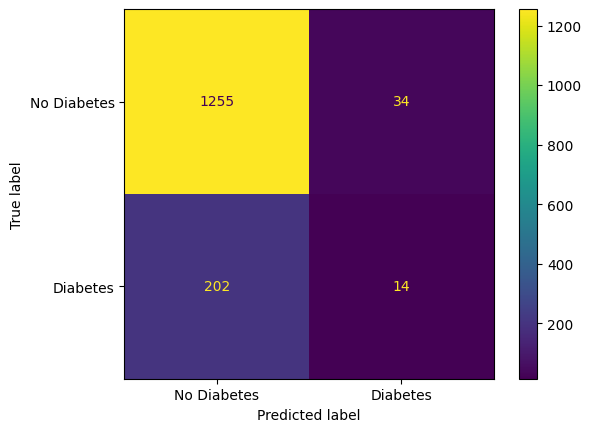

In [33]:
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

This performs the same function as it did for the Decision Tree, using the trained model to make predictions on the X_test dataset. These predictions are then stored in the y_pred variable. This array will contain the classification of each patient in the test set.

**XGBoost**

In [34]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

This trains the XGBoosst model. This is similar to the Logistic Regression and Decision Tree models, used to train the model. X_train contains the features of the training data while y_train contains the target labels of the training data. The relationship between the features and the outcomes is being learned.

In [35]:
#Get the prediction for the patient we've been tracking through
prediction = xgb.predict(patient)[0]
print(prediction)

1


This line uses the trained model to make a prediction for the patient DataFrame extracted prior. This contains the features for this specific patient. This provides the predicted outcome and is assigned to the "prediction" variable.

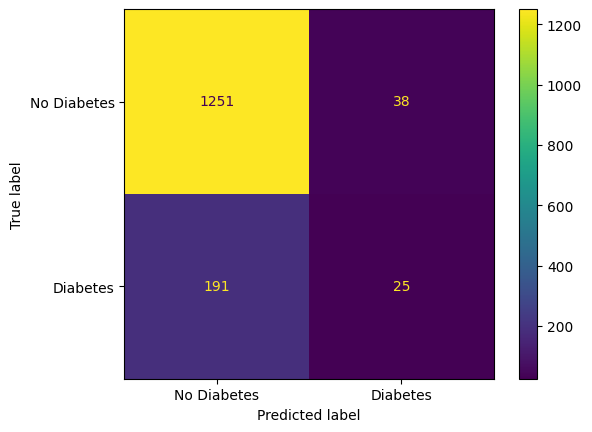

In [36]:
y_pred = xgb.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

This performs the same function as the XGBoost model for the Random Forest model. Predictions are being main based on the X_set dataset, which contains the features for all patients in the test set. These predictions are stored in the y_pred variable. This uses the model to classify all patients in the test set, providing the predicted Diabetes status for each patient.

**Neural Networks**

In [37]:
nn = MLPClassifier(random_state=42, max_iter=500)
nn.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(max_iter=500, random_state=42)

This initializes the Neural Network model and trains it using the training data.

In [38]:
#Get the prediction for the patient we've been tracking throughout
prediction = nn.predict(patient)[0]
print(prediction)

0


This line uses the trained model to make a prediction for the patient DataFrame. The [0] access the first element, only giving the single predicted outcome. This result is stored in the "prediction" variable.

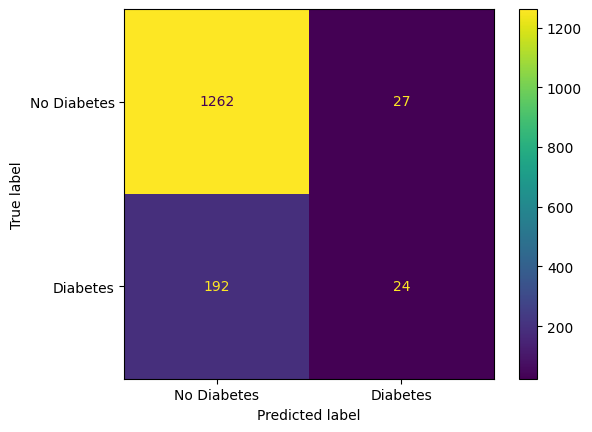

In [39]:

y_pred = nn.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

This line generates a Confusion Matrix, used to describe the performance of the classification model on the test set. The y_test displays the true Diabetes statuses of the patients in the test set. The y_pred refers to the predictions that the model made for the patients. The matrix visualizes how many of these predictions were correct and incorrect. The "plt.show()" command us used to displau the plot created by the Matrix display from the predictions, evaluating the performance of the Neural Network model on the entire test dataset by summarizing the classifications, both correct and incorrect.